# Notebook for Week 6 submission
#### Tristan Cornwell - V00993072

### Part 1: Get the sample data

In [58]:
%%bash
set -euo pipefail
wget -O 3M-february-2018.txt.gz https://github.com/f0t1h/3M-february-2018/raw/refs/heads/master/3M-february-2018.txt.gz
curl -L -o toy_read_ref_set.tar.gz "https://public.boxcloud.com/d/1/b1!kr3o15jxvOpV4BmoMb7XM7Cvej0t7L06cBRVmRjOPBJTylc1TTbvsxCONQuzOwOpnxQSOx5nyUXwQGP_5A0ziuih8640DJ3_ezp4ErQ7c-AIf1YhjzFCgF3MELAU9wu6J7xt7lX1ZHH_J8s0lyL3KnMU8vRH4ItZyN2TQBcRo4cAKPD1qK9n-mstnmDdo_J7KEM0A5WJqTCwIxYvI7dyl_xSxx4aNi0Jr2njXd5OwuuranT0N0UFc9Yy81Ffh1NkXswOVlms8l4MrkVYRYGBSHKX037FSZrNUOadc0Tuq5-YPXkUsBzjatbJ47rA0zZmWjEGVzI2A6v6CuQVP84aHuY7AydMvzsYZTDGha0efgoFr8VNQZkYw-AtlDxLCUu9QEmmsxNbwFweD9oc0_Zr1atwC_GMewHlK9SZgYJ_gnZgNKlDeyf9--VaRNMLD1RwQA1fL8lDjzB-sY-w-Sf7PpJt349q9q9F08arw0sz1bUFjSmBUWifGufvCU6fs9D-Kj8QRpwhj0FAGf0ExYMYRQCjaRLbFIS2HjSmFnU17w7-uUEBHGM_TNIX4IS600SRah_1naPFN2aTQbPbtGz2PihfQST4GxTbHVrWcsP8nzjtRg9D9JiR7H34jy5NGmIai2mqttcXFTOgrQdNgjYSx1QlVOokE53uHDJHbuW4TyqK-XAGxV00KjEGtNTH-un4wR712bjE4wfNOiWDsHYFt8n7S94gCh_A9xxf1sQJpJP0l5jFUpUhsnQZxCmYK8-l-ZbLXKnsXtPLKNIAnOEAe83pn__VjJg28zEVd5AFv7uGieDUnBJhRyCe2XVHUa5zkPJxHjEFsO46VMcQXFTCjW9bjIp7ujG3MpZOBjDDqy8etL0YNTtIKj0tqwpVwOHtUzuPA7vq-ztOsOB7Zg28E__3B023ytkkMolBxQ183dfSnwVxQSFowXBE2n8CtvWMycm_xvBENgazeJogkVyIJuyoviE6swrU2_bDdNV47lCJ169D6pV99KYZEgEmAVrWACDQTu32YboOL3VTSKo_Yx-ckOOE8jstdZWdJVI9Ax6h3DA9CBftFjccmbC8-oTzh9ODY_1xPWPWCCSA7GXB1XVgxxt2QLF41qKCuYiOkrQkinzIpAVfFwOsh8bz5xR6NrHSz-zFkxNaLV2DHZW7S-sdqDvGfebjx1JMyS__DUql1db9pcfEGC0WQITxwcQglALHo-vFHhaTPDOytUZsOJ8Y_zTgE5muVqiZC5ZBhHQ2oWwlvmsXhz0w9AcpQlRiTssqBxEsOVoQb5U_63OxJEFxNTVso8d2sCKP47Kp2KiB_aRsS8_XUgD00WbTOUVyVimBo2XdjRtPvScO04sIH8hevunieCqciBI8BlcFdSHezKZPCdgBcy5SxfRc5hD0an4scMH4EMbz7heDWYr-NFsC8DyD3DvGbm_-kRpAwWsHxsRd9KVVc2khtN59-He3J7fX2w../download"
gunzip -f 3M-february-2018.txt.gz
tar xzf toy_read_ref_set.tar.gz --strip-components=1 -C . 
rm -rf toy_read_ref_set.tar.gz


Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
--2025-11-16 20:35:42--  https://github.com/f0t1h/3M-february-2018/raw/refs/heads/master/3M-february-2018.txt.gz
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/f0t1h/3M-february-2018/refs/heads/master/3M-february-2018.txt.gz [following]
--2025-11-16 20:35:42--  https://raw.githubusercontent.com/f0t1h/3M-february-2018/refs/heads/master/3M-february-2018.txt.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18350152 (18M) [application/octet-stream]
Saving to: '3M-february-2018.txt.gz'

### Part 2: Align and Quantify with Alevin-Fry

In [59]:
%%bash
rm -rf alevin_fry_home
mkdir alevin_fry_home
# the simpleaf set-paths command finds the path to the required tools and writes a configuration JSON file in the ALEVIN_FRY_HOME folder.
export ALEVIN_FRY_HOME='alevin_fry_home'
simpleaf set-paths
simpleaf index \
-o simpleaf_index \
-f toy_human_ref/fasta/genome.fa \
-g toy_human_ref/genes/genes.gtf \
-r 90 \
-t 8

found `piscem` in the PATH at /home/tcornwell/miniconda3/envs/bioinfo/bin/piscem
found `salmon` in the PATH at /home/tcornwell/miniconda3/envs/bioinfo/bin/salmon
found `alevin-fry` in the PATH at /home/tcornwell/miniconda3/envs/bioinfo/bin/alevin-fry
2025-11-17T04:35:50.072474Z  WARN simpleaf::utils::prog_utils: Could not find macs3 executable, peak calling cannot be peformed by simpleaf


Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


2025-11-17T04:35:50.200493Z  WARN simpleaf::utils::prog_utils: It is recommended to use piscem version >=0.12.0, but currently version 0.11.0 is being used. Please consider installing the latest version of piscem and setting simpleaf to use this new version by running the `refresh-prog-info` command.
2025-11-17T04:35:50.200568Z  INFO simpleaf::utils::af_utils: The directory simpleaf_index doesn't yet exist; attempting to create it.
2025-11-17T04:35:50.201056Z  INFO simpleaf::utils::af_utils: The directory simpleaf_index/ref doesn't yet exist; attempting to create it.
2025-11-17T04:35:50.201343Z  INFO simpleaf::simpleaf_commands::indexing: preparing to make reference with roers
2025-11-17T04:35:50.210500Z  INFO grangers::reader::gtf: Finished parsing the input file. Found 3 comments and 2439 records.
2025-11-17T04:35:50.217156Z  INFO roers: Built the Grangers object for 2439 records
2025-11-17T04:35:50.288769Z  WARN grangers::grangers_info: The exon_number column contains null values. W

In [60]:
%%bash 
export ALEVIN_FRY_HOME='alevin_fry_home'
# Collecting sequencing read files
## The reads1 and reads2 variables are defined by finding the filenames with the pattern "_R1_" and "_R2_" from the toy_read_fastq directory.
reads1_pat="_R1_"
reads2_pat="_R2_"

## The read files must be sorted and separated by a comma.
### The find command finds the files in the fastq_dir with the name pattern
### The sort command sorts the file names
### The awk command and the paste command together convert the file names into a comma-separated string.
reads1="$(find -L ${fastq_dir} -name "*$reads1_pat*" -type f | sort | awk -v OFS=, '{$1=$1;print}' | paste -sd,)"
reads2="$(find -L ${fastq_dir} -name "*$reads2_pat*" -type f | sort | awk -v OFS=, '{$1=$1;print}' | paste -sd,)"

# simpleaf quant
## Usage: simpleaf quant -c chemistry -t threads -1 reads1 -2 reads2 -i index -u [unspliced permit list] -r resolution -m t2g_3col -o output_dir
simpleaf quant \
-c 10xv3 -t 8 \
-1 $reads1 -2 $reads2 \
-i simpleaf_index/index \
-u -r cr-like \
-m simpleaf_index/index/t2g_3col.tsv \
-o simpleaf_quant

2025-11-17T04:35:59.911876Z  WARN simpleaf::utils::prog_utils: It is recommended to use piscem version >=0.12.0, but currently version 0.11.0 is being used. Please consider installing the latest version of piscem and setting simpleaf to use this new version by running the `refresh-prog-info` command.


Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


2025-11-17T04:36:00.144574Z  INFO simpleaf::utils::af_utils: The directory alevin_fry_home/plist doesn't yet exist; attempting to create it.
2025-11-17T04:36:00.145122Z  INFO simpleaf::utils::af_utils: Expected alevin_fry_home/plist/2c9dfb98babe5a57ae763778adb9ebb7bfa531e105823bc26163892089333f8c but didn't find it, will try to download it using a remote url.
2025-11-17T04:36:04.029634Z  INFO simpleaf::simpleaf_commands::quant: found uncompressed file
2025-11-17T04:36:04.032366Z  INFO simpleaf::simpleaf_commands::quant: piscem map-sc cmd : /home/tcornwell/miniconda3/envs/bioinfo/bin/piscem map-sc --index simpleaf_index/index/piscem_idx --threads 8 -o simpleaf_quant/af_map --max-ec-card 4096 --skipping-strategy permissive --max-hit-occ 256 --max-hit-occ-recover 1024 --max-read-occ 2500 -1 ./toy_read_fastq/selected_R1_reads.fastq -2 ./toy_read_fastq/selected_R2_reads.fastq --geometry chromium_v3
2025-11-17T04:36:04.217343Z  INFO simpleaf::utils::prog_utils: command returned successfully 

### Part 3: Clustering

USA mode: True
Processing user-defined output format.
Will populate output field X with sum of counts frorm ['U', 'S', 'A'].


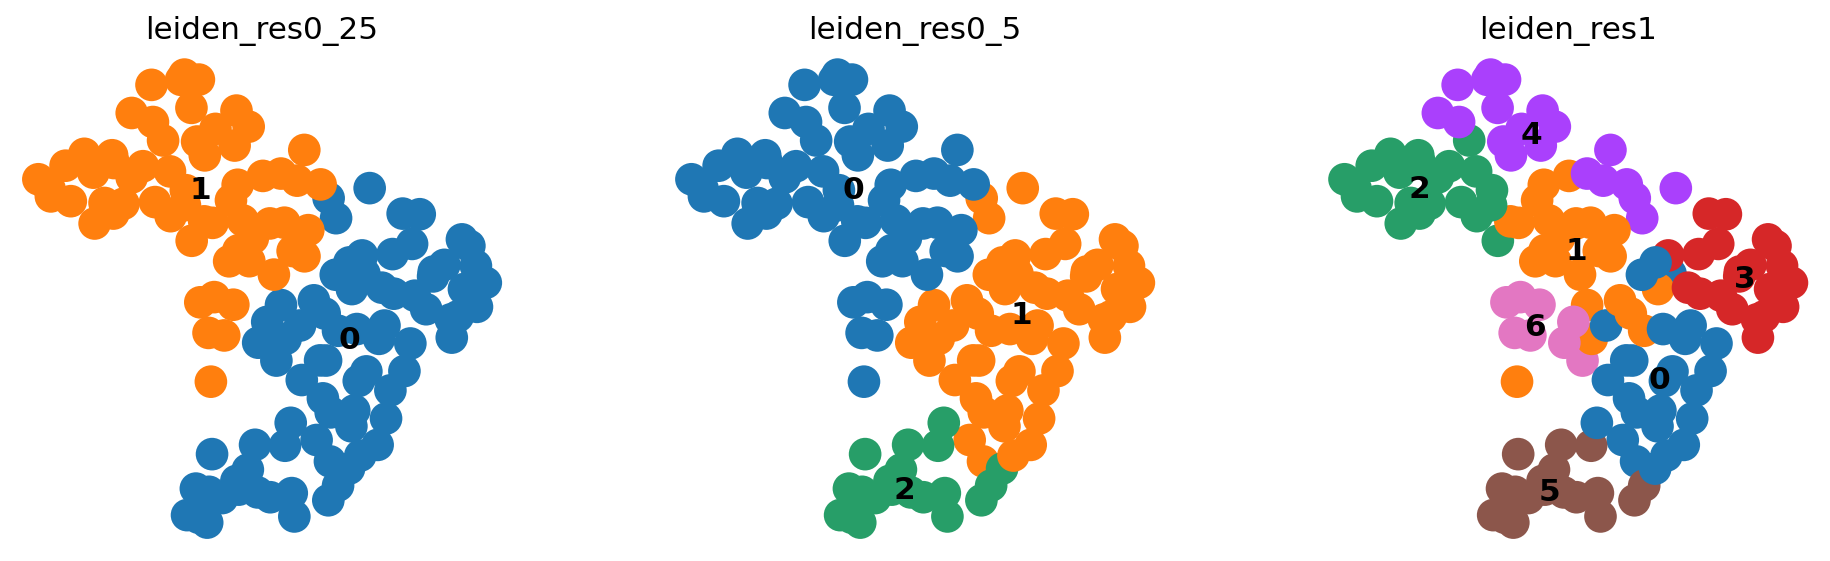

In [61]:
import pyroe
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.verbosity = 0
sc.settings.set_figure_params(dpi=80, facecolor="white", frameon=False)

quant_dir = 'simpleaf_quant/af_quant'
adata_usa = pyroe.load_fry(quant_dir, output_format={'X' : ['U','S','A']})

sc.pp.neighbors(adata_usa, n_pcs=30)
sc.tl.umap(adata_usa)

sc.tl.leiden(adata_usa, resolution=0.25, key_added="leiden_res0_25")
sc.tl.leiden(adata_usa, resolution=0.5, key_added="leiden_res0_5")
sc.tl.leiden(adata_usa, resolution=1.0,key_added="leiden_res1",)

sc.pl.umap(
    adata_usa,
    color=["leiden_res0_25", "leiden_res0_5", "leiden_res1"],
    legend_loc="on data",
)

### Part 4: Annotation

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
querying 1-20 ...


USA mode: True
Processing user-defined output format.
Will populate output field X with sum of counts frorm ['U', 'S', 'A'].


HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
Finished.
📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 58
📂 Storing models in /home/tcornwell/.celltypist/data/models
💾 Total models to download: 2
💾 Downloading model [1/2]: Immune_All_Low.pkl
💾 Downloading model [2/2]: Immune_All_High.pkl
🔬 Input data has 139 cells and 20 genes
🔗 Matching reference genes in the model
🧬 10 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!
🔬 Input data has 139 cells and 20 genes
🔗 Matching reference genes in the model
🧬 10 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will r

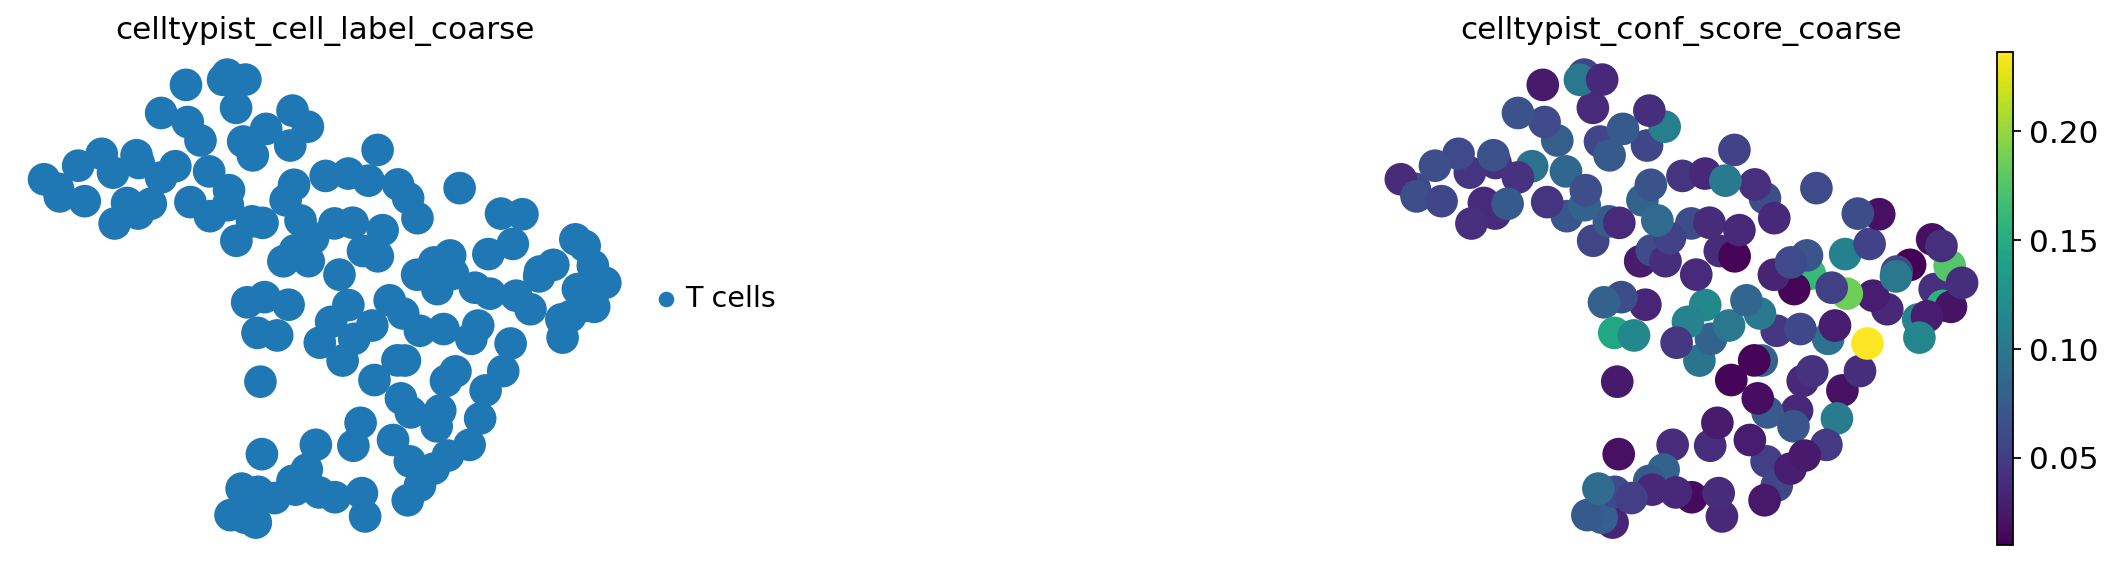

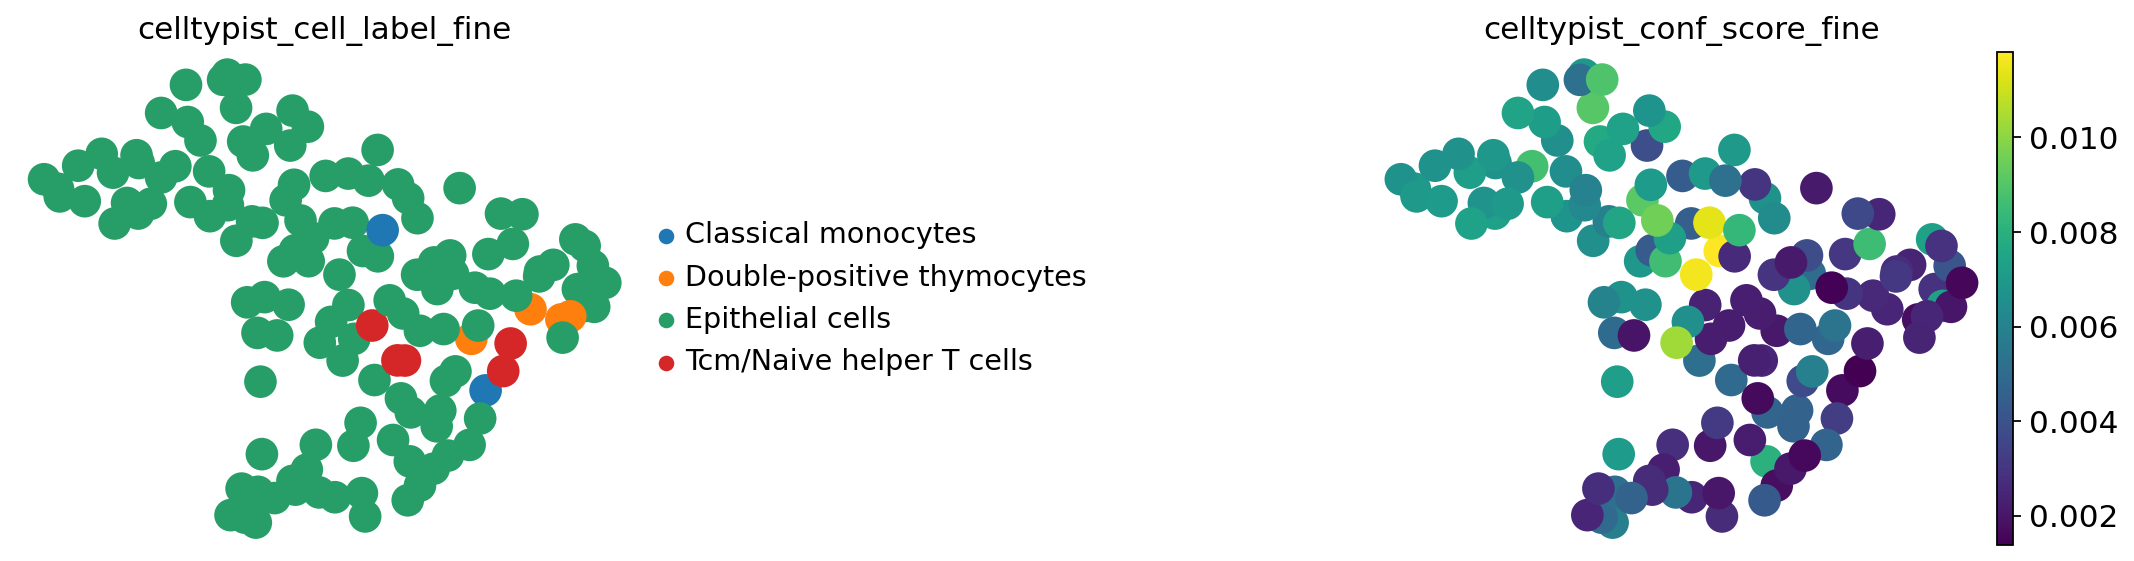

In [62]:
import celltypist
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from celltypist import models
from scipy.sparse import csr_matrix
import mygene

quant_dir = 'simpleaf_quant/af_quant'
adata_usa = pyroe.load_fry(quant_dir, output_format={'X' : ['U','S','A']})
sc.pp.neighbors(adata_usa, n_pcs=30)
sc.tl.umap(adata_usa)


# convert ensembl IDs to gene symbols for compatibility with CellTypist models
mg = mygene.MyGeneInfo()
# Query Ensembl IDs → gene symbols
ensg = adata_usa.var_names.tolist()
out = mg.querymany(ensg, scopes="ensembl.gene", fields="symbol", species="human")

# Build mapping dictionary
mapping = {item["query"]: item.get("symbol", None) for item in out}
adata_usa.var["gene_symbol"] = adata_usa.var_names.map(mapping)
adata_usa = adata_usa[:, adata_usa.var["gene_symbol"].notnull()].copy()
adata_usa.var_names = adata_usa.var["gene_symbol"]

# Preprocess data for CellTypist
adata_celltypist = adata_usa.copy()  # make a copy of our adata

adata_celltypist.X = adata_usa.X # set adata.X to raw counts
sc.pp.normalize_total(
    adata_celltypist, target_sum=10**4
)  # normalize to 10,000 counts per cell
sc.pp.log1p(adata_celltypist)  # log-transform
# make .X dense instead of sparse, for compatibility with celltypist:
adata_celltypist.X = adata_celltypist.X.toarray()


models.download_models(
    force_update=True, model=["Immune_All_Low.pkl", "Immune_All_High.pkl"]
)
model_low = models.Model.load(model="Immune_All_Low.pkl")
model_high = models.Model.load(model="Immune_All_High.pkl")

# coarse predictions
predictions_high = celltypist.annotate(
    adata_celltypist, model=model_high, majority_voting=True
)
predictions_high_adata = predictions_high.to_adata()
adata_usa.obs["celltypist_cell_label_coarse"] = predictions_high_adata.obs.loc[
    adata_usa.obs.index, "majority_voting"
]
adata_usa.obs["celltypist_conf_score_coarse"] = predictions_high_adata.obs.loc[
    adata_usa.obs.index, "conf_score"
]

# fine predictions
predictions_low = celltypist.annotate(
    adata_celltypist, model=model_low, majority_voting=True
)
predictions_low_adata = predictions_low.to_adata()
adata_usa.obs["celltypist_cell_label_fine"] = predictions_low_adata.obs.loc[
    adata_usa.obs.index, "majority_voting"
]
adata_usa.obs["celltypist_conf_score_fine"] = predictions_low_adata.obs.loc[
    adata_usa.obs.index, "conf_score"
]

sc.pl.umap(
    adata_usa,
    color=["celltypist_cell_label_coarse", "celltypist_conf_score_coarse"],
    frameon=False,
    sort_order=False,
    wspace=1,
)
sc.pl.umap(
    adata_usa,
    color=["celltypist_cell_label_fine", "celltypist_conf_score_fine"],
    frameon=False,
    sort_order=False,
    wspace=1,
)

### Cleanup

In [63]:
%%bash
rm -rf alevin_fry_home simpleaf_quant simpleaf_index toy_human_ref toy_read_fastq workdir.noindex 3M-february-2018.txt

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
